# Análisis adicional de intermitencia (sin reentrenamiento)
Este notebook consume el dataset semanal y las predicciones comunes **existentes**. Preserva las 3444 observaciones de 129 series por modelo y no altera el experimento base, el target ni Streamlit.

El resumen anterior de ceros se conserva en sus CSV. La nueva clasificación usa únicamente TRAIN previo al corte, ADI=N/N+ y CV² de tamaños positivos (varianza muestral ddof=1), con cortes publicados 1.32/0.49. Se mantienen categorías explícitas para historia/positivas insuficientes. Ver metodología, referencias y borradores en `docs/ANALISIS_INTERMITENCIA.md`.


In [1]:
import sys
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
from src.analisis_intermitencia import ejecutar
pd.options.display.float_format = '{:.4f}'.format
tablas = ejecutar(ROOT)
display(tablas['distribucion_intermitencia.csv'])
display(tablas['metricas_por_intermitencia.csv'])
display(tablas['metricas_por_grupo_demanda.csv'])
display(tablas['metricas_cero_vs_positivo.csv'])
display(tablas['auditoria_predicciones_negativas.csv'])
display(tablas['evaluacion_despliegue.csv'])
print('No se entrenaron modelos ni se modificaron predicciones o app.py.')


,clasificacion_demanda,Series_comunes,Series_dataset
0,suave,1,1
1,erratica,0,0
2,intermitente,63,100
3,lumpy,5,6
4,positivas_insuficientes,23,39
5,sin_demanda_positiva,37,72
6,sin_historia_train,0,22


,Modelo,Clasificacion_demanda,MAE,RMSE,R2,Observaciones,Series,Varianza_y_real,SST,Porcentaje_ceros_test,R2_estado,Advertencias
0,Regresión Lineal,suave,0.8246,1.0476,-0.0725,30,1,1.0233,30.7000,43.3333,definido,una_sola_serie
1,Random Forest,suave,0.8666,1.1091,-0.2021,30,1,1.0233,30.7000,43.3333,definido,una_sola_serie
2,XGBoost,suave,0.9025,1.1102,-0.2043,30,1,1.0233,30.7000,43.3333,definido,una_sola_serie
3,ARIMA (Optimizado ADF/AIC),suave,0.8666,1.1145,-0.2137,30,1,1.0233,30.7000,43.3333,definido,una_sola_serie
4,Regresión Lineal,erratica,NaN,NaN,NaN,0,0,NaN,NaN,NaN,sin_observaciones,grupo_ausente
5,Random Forest,erratica,NaN,NaN,NaN,0,0,NaN,NaN,NaN,sin_observaciones,grupo_ausente
6,XGBoost,erratica,NaN,NaN,NaN,0,0,NaN,NaN,NaN,sin_observaciones,grupo_ausente
7,ARIMA (Optimizado ADF/AIC),erratica,NaN,NaN,NaN,0,0,NaN,NaN,NaN,sin_observaciones,grupo_ausente
8,Regresión Lineal,intermitente,0.3839,0.7201,0.2814,1669,63,0.7216,1204.3056,78.2504,definido,
9,Random Forest,intermitente,0.3852,0.7352,0.2510,1669,63,0.7216,1204.3056,78.2504,definido,


,Modelo,grupo_demanda,MAE,RMSE,R2,Observaciones,Series,Varianza_y_real,SST,Porcentaje_ceros_test,R2_estado,Advertencias
0,Regresión Lineal,menor_intermitencia,0.8246,1.0476,-0.0725,30,1,1.0233,30.7000,43.3333,definido,una_sola_serie
1,Random Forest,menor_intermitencia,0.8666,1.1091,-0.2021,30,1,1.0233,30.7000,43.3333,definido,una_sola_serie
2,XGBoost,menor_intermitencia,0.9025,1.1102,-0.2043,30,1,1.0233,30.7000,43.3333,definido,una_sola_serie
3,ARIMA (Optimizado ADF/AIC),menor_intermitencia,0.8666,1.1145,-0.2137,30,1,1.0233,30.7000,43.3333,definido,una_sola_serie
4,Regresión Lineal,mayor_intermitencia,0.3075,0.6336,0.3013,2388,91,0.5746,1372.2425,83.2077,definido,
5,Random Forest,mayor_intermitencia,0.3030,0.6433,0.2798,2388,91,0.5746,1372.2425,83.2077,definido,
6,XGBoost,mayor_intermitencia,0.2972,0.6439,0.2785,2388,91,0.5746,1372.2425,83.2077,definido,
7,ARIMA (Optimizado ADF/AIC),mayor_intermitencia,0.3266,0.6818,0.1911,2388,91,0.5746,1372.2425,83.2077,definido,
8,Regresión Lineal,sin_demanda_positiva,0.0343,0.1047,-0.1319,1026,37,0.0097,9.9376,99.3177,definido,varianza_menor_que_global;porcentaje_ceros_may...
9,Random Forest,sin_demanda_positiva,0.0315,0.1067,-0.1764,1026,37,0.0097,9.9376,99.3177,definido,varianza_menor_que_global;porcentaje_ceros_may...


,Modelo,Tipo_demanda,MAE,RMSE,R2,Observaciones,Series,Varianza_y_real,SST,Porcentaje_ceros_test,R2_estado,Advertencias
0,Regresión Lineal,cero,0.1253,0.2653,NaN,3019,129,0.0000,0.0000,100.0000,no_definido_target_constante,porcentaje_ceros_mayor_que_global
1,Random Forest,cero,0.1211,0.2961,NaN,3019,129,0.0000,0.0000,100.0000,no_definido_target_constante,porcentaje_ceros_mayor_que_global
2,XGBoost,cero,0.1160,0.2824,NaN,3019,129,0.0000,0.0000,100.0000,no_definido_target_constante,porcentaje_ceros_mayor_que_global
3,ARIMA (Optimizado ADF/AIC),cero,0.1245,0.3318,NaN,3019,129,0.0000,0.0000,100.0000,no_definido_target_constante,porcentaje_ceros_mayor_que_global
4,Regresión Lineal,positiva,0.9787,1.3638,-0.6090,425,66,1.1559,491.2612,0.0000,definido,
5,Random Forest,positiva,0.9794,1.3479,-0.5717,425,66,1.1559,491.2612,0.0000,definido,
6,XGBoost,positiva,1.0006,1.3692,-0.6219,425,66,1.1559,491.2612,0.0000,definido,
7,ARIMA (Optimizado ADF/AIC),positiva,1.0306,1.3931,-0.6791,425,66,1.1559,491.2612,0.0000,definido,


,Modelo,Predicciones_negativas,Porcentaje_predicciones_negativas,Minimo_predicho,MAE_negativas,RMSE_negativas,Negativas_con_y_cero,Negativas_con_y_positivo,Mediana_absoluta_negativas,Percentil95_absoluto_negativas
0,Regresión Lineal,684,19.8606,-0.0552,0.0346,0.1573,676,8,0.0191,0.0416
1,Random Forest,0,0.0000,0.0068,NaN,NaN,0,0,NaN,NaN
2,XGBoost,0,0.0000,0.0237,NaN,NaN,0,0,NaN,NaN
3,ARIMA (Optimizado ADF/AIC),1048,30.4297,-0.2625,0.0119,0.1244,1038,10,0.0000,0.0000


,Modelo,MAE_global,RMSE_global,R2_global,MAE_menor_intermitencia,RMSE_menor_intermitencia,Series_menor_intermitencia,MAE_mayor_intermitencia,RMSE_mayor_intermitencia,Series_mayor_intermitencia,MAE_demanda_positiva,RMSE_demanda_positiva,Predicciones_negativas,Porcentaje_predicciones_negativas,Series_cubiertas,Observaciones_cubiertas,Observaciones_metricas_comunes,Series_metricas_comunes,Criterio_cobertura
0,Regresión Lineal,0.2306,0.5396,0.3219,0.8246,1.0476,1,0.3075,0.6336,91,0.9787,1.3638,684.0000,19.8606,156,3940,3444,129,"propia, sólo cobertura; todas las métricas son..."
1,Random Forest,0.2270,0.5487,0.2989,0.8666,1.1091,1,0.3030,0.6433,91,0.9794,1.3479,0.0000,0.0000,156,3940,3444,129,"propia, sólo cobertura; todas las métricas son..."
2,XGBoost,0.2252,0.5489,0.2984,0.9025,1.1102,1,0.2972,0.6439,91,1.0006,1.3692,0.0000,0.0000,156,3940,3444,129,"propia, sólo cobertura; todas las métricas son..."


No se entrenaron modelos ni se modificaron predicciones o app.py.


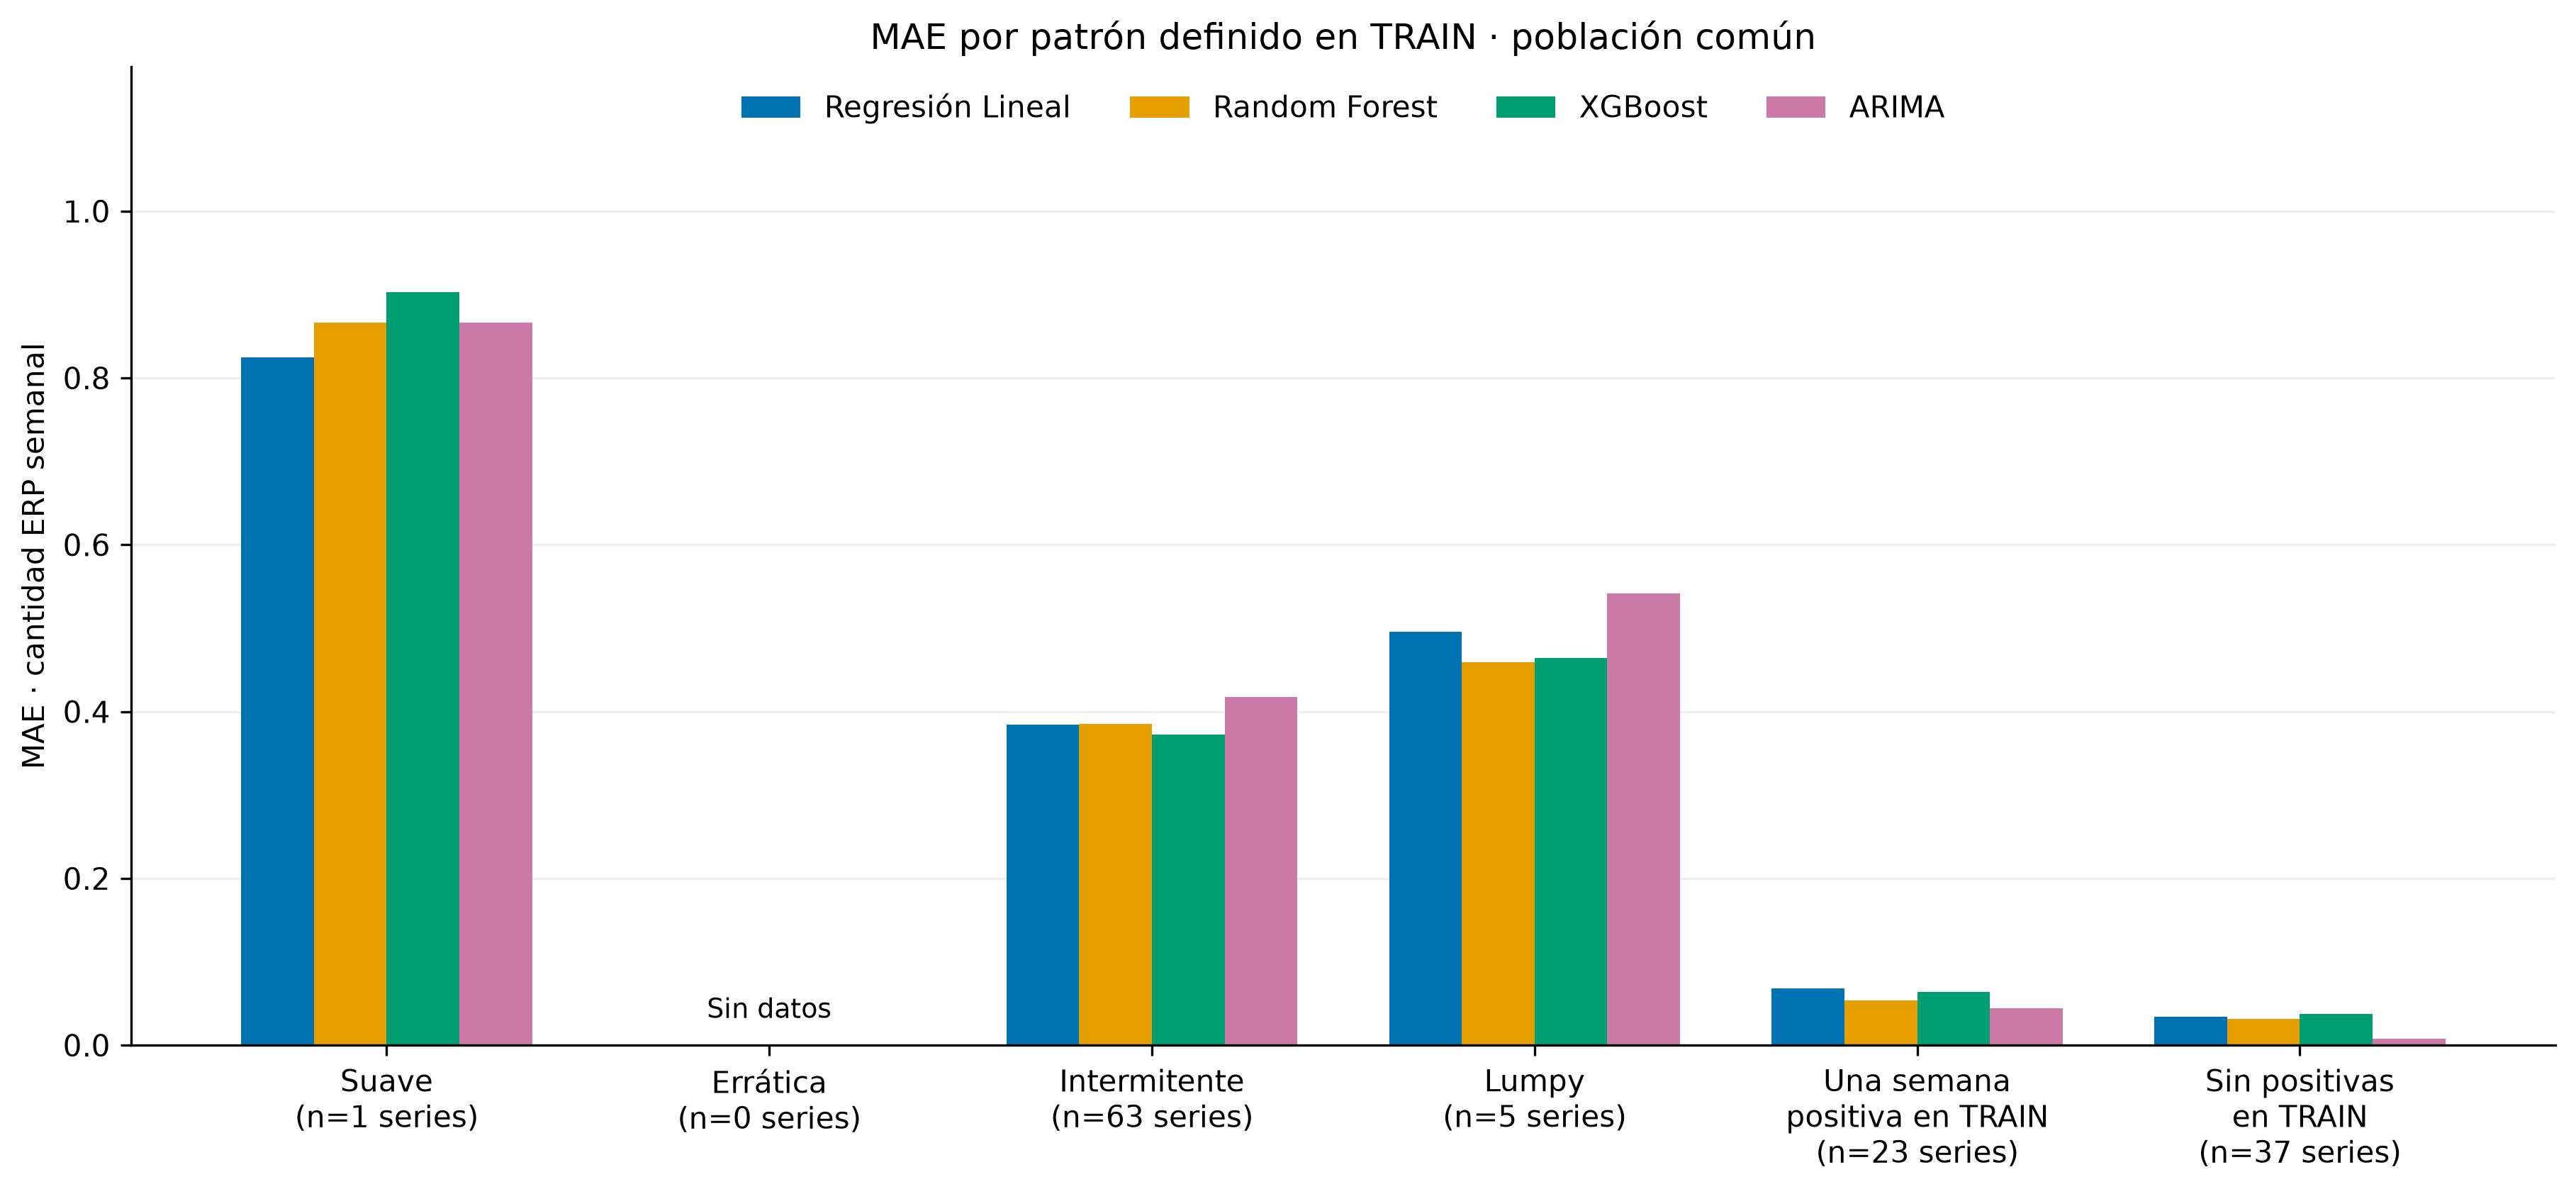

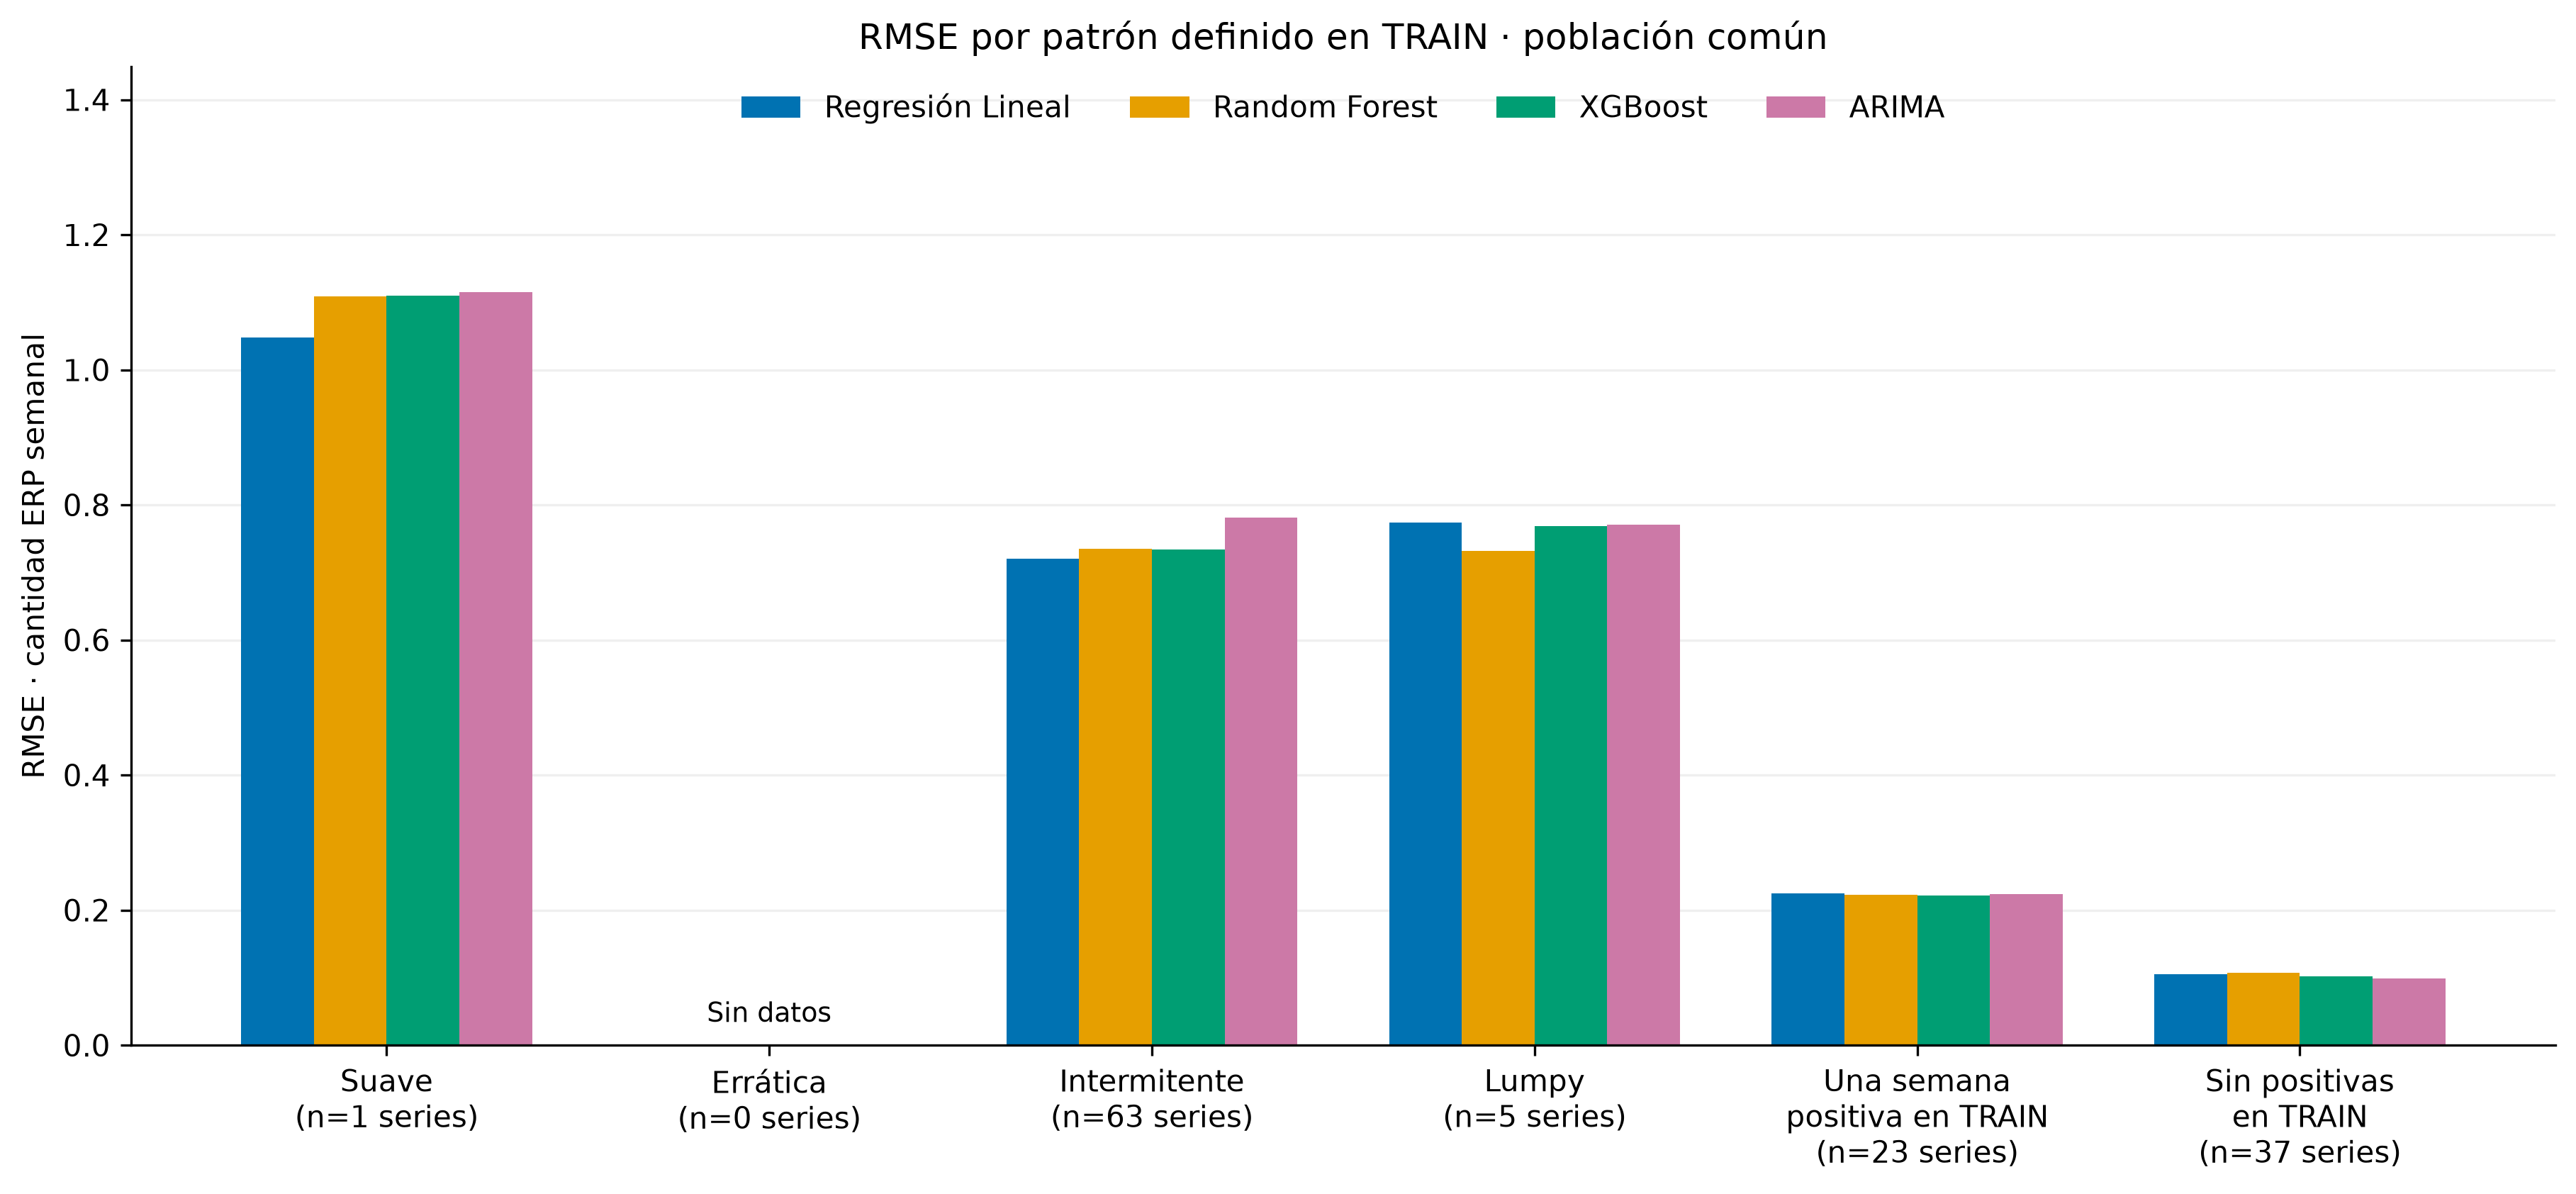

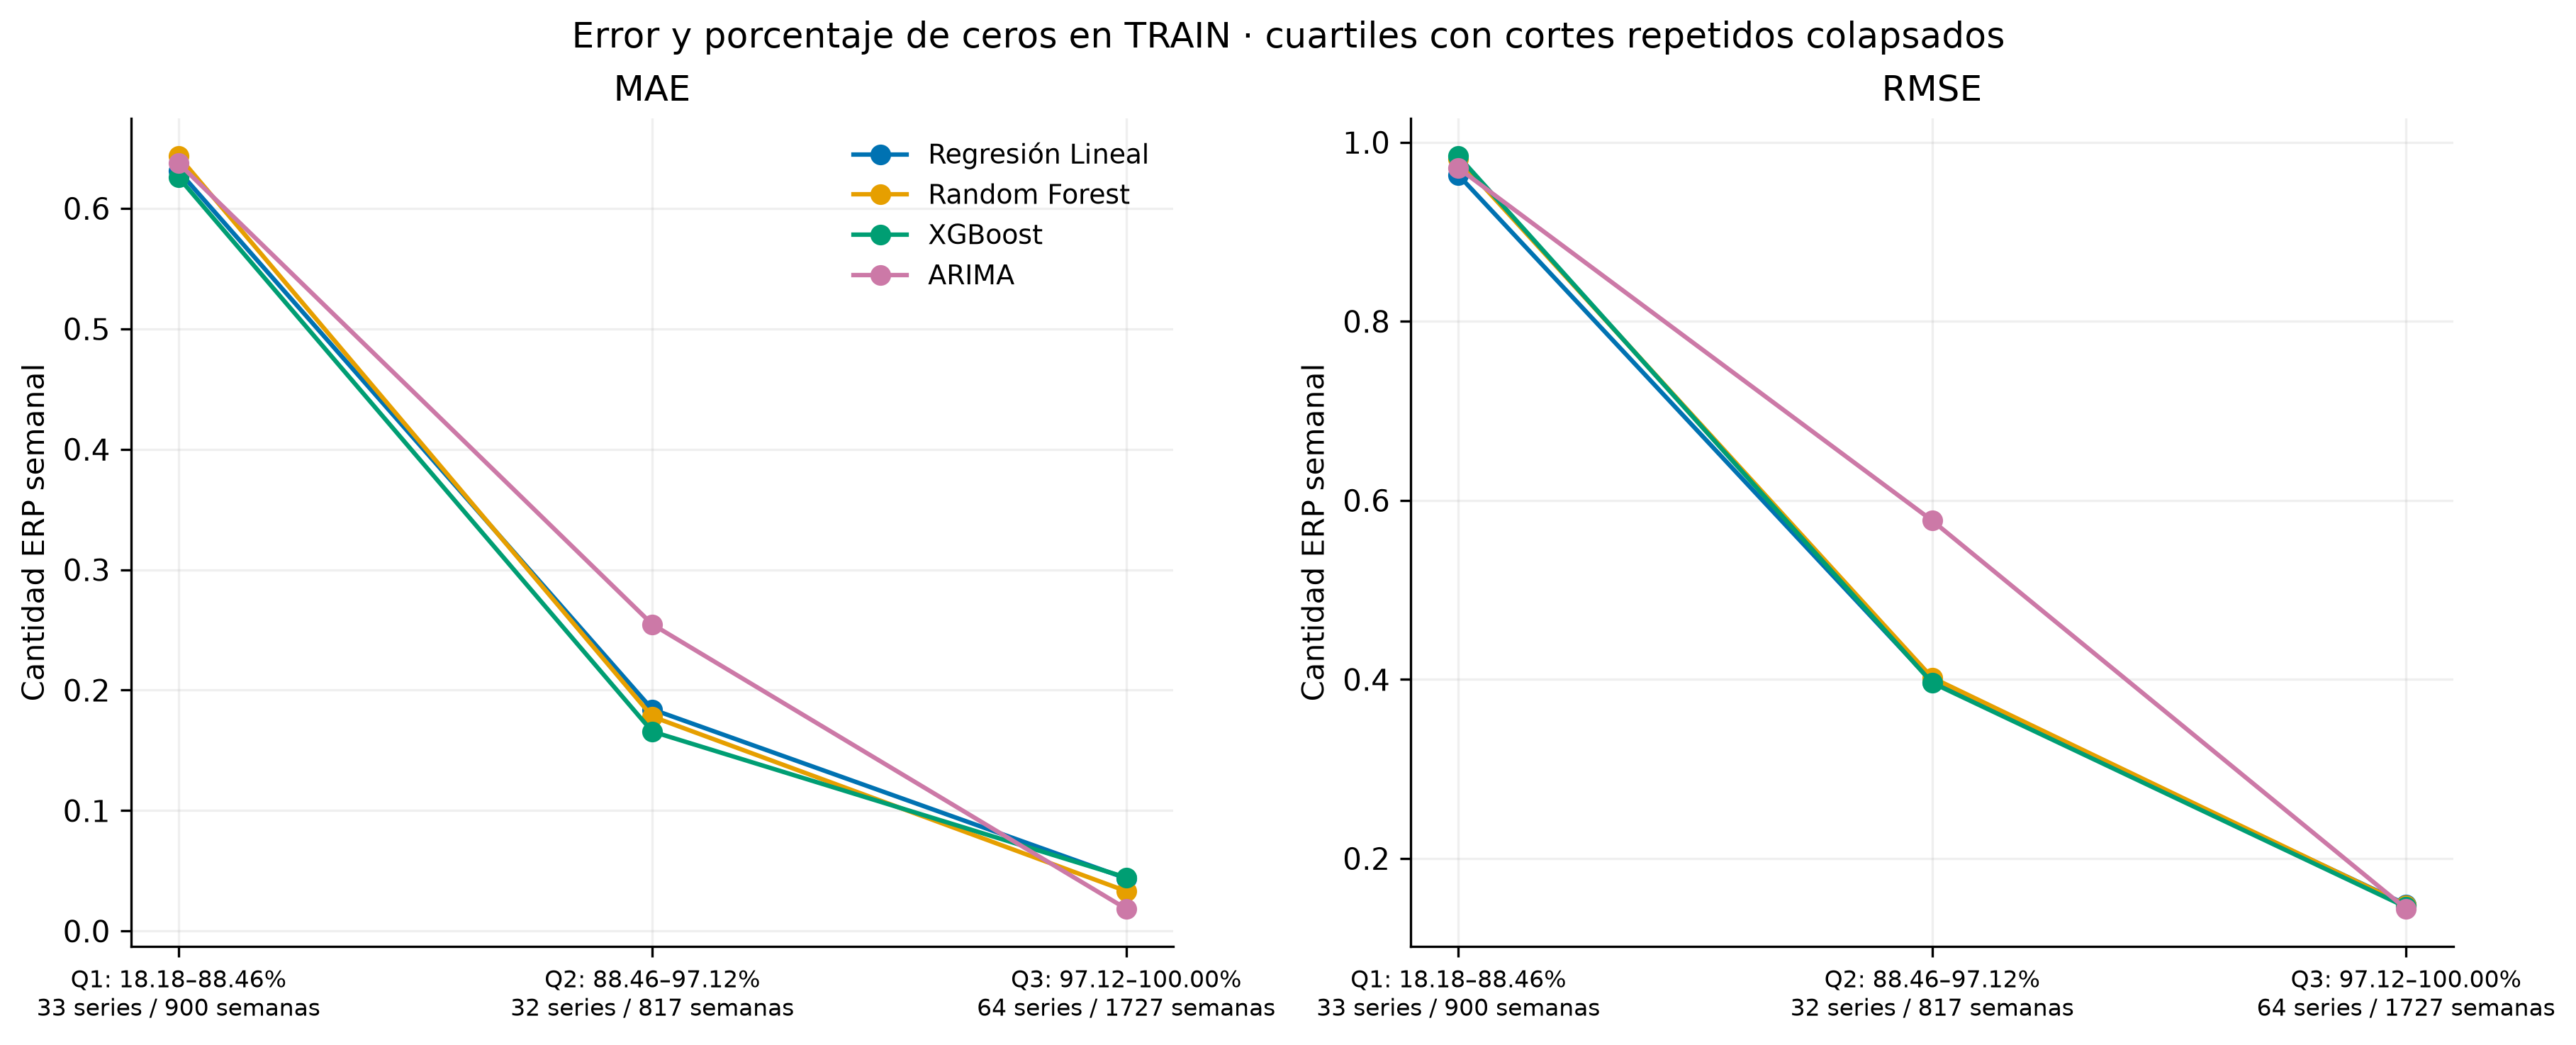

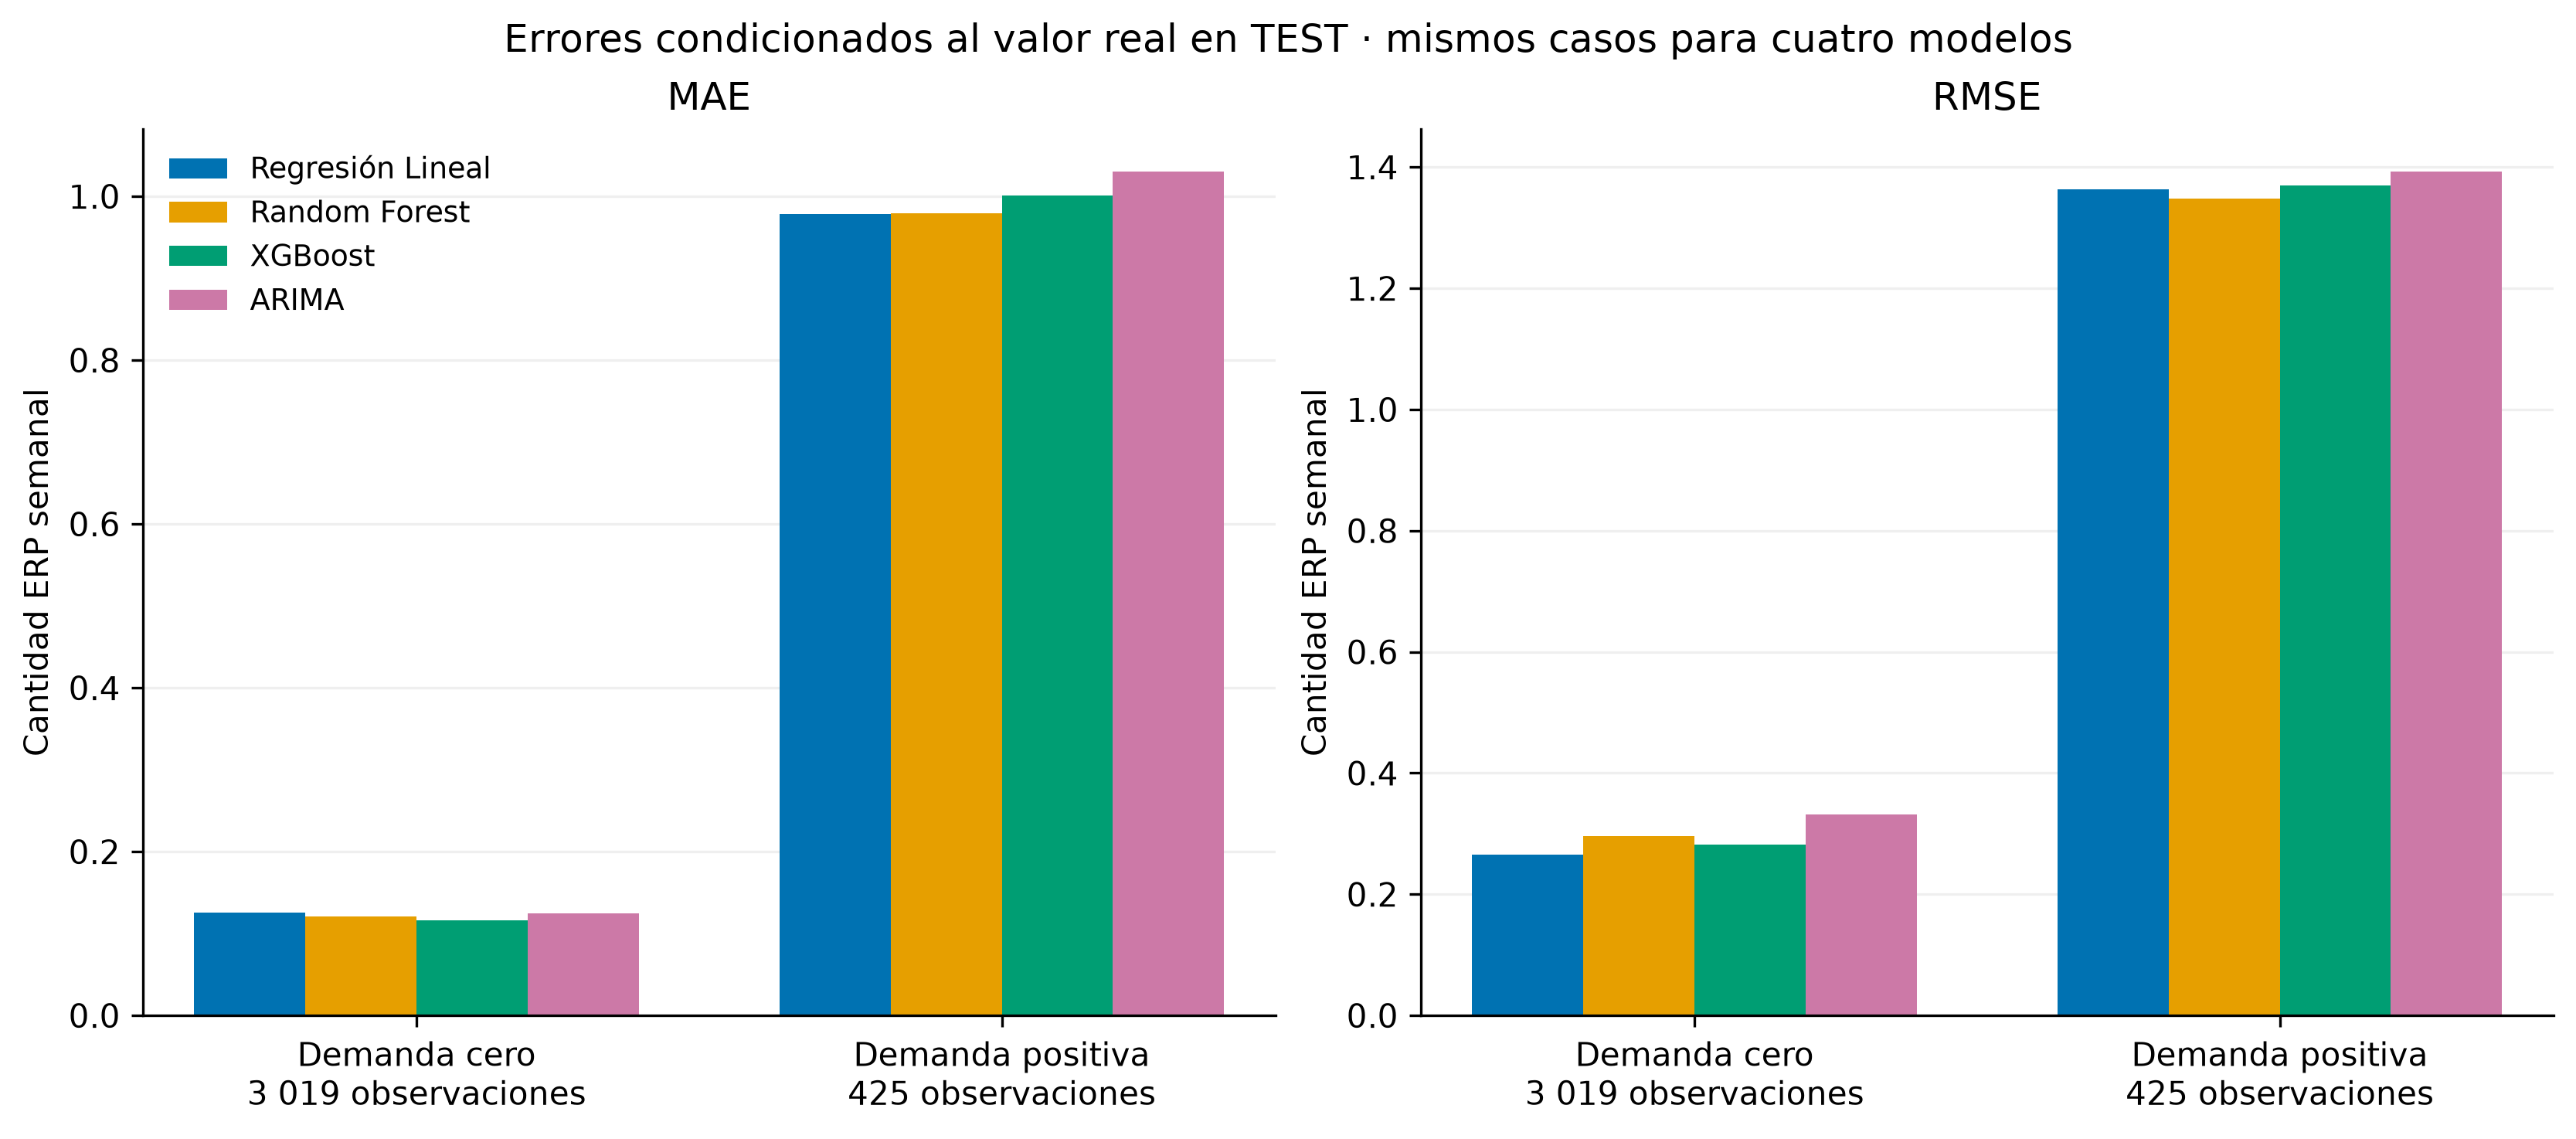

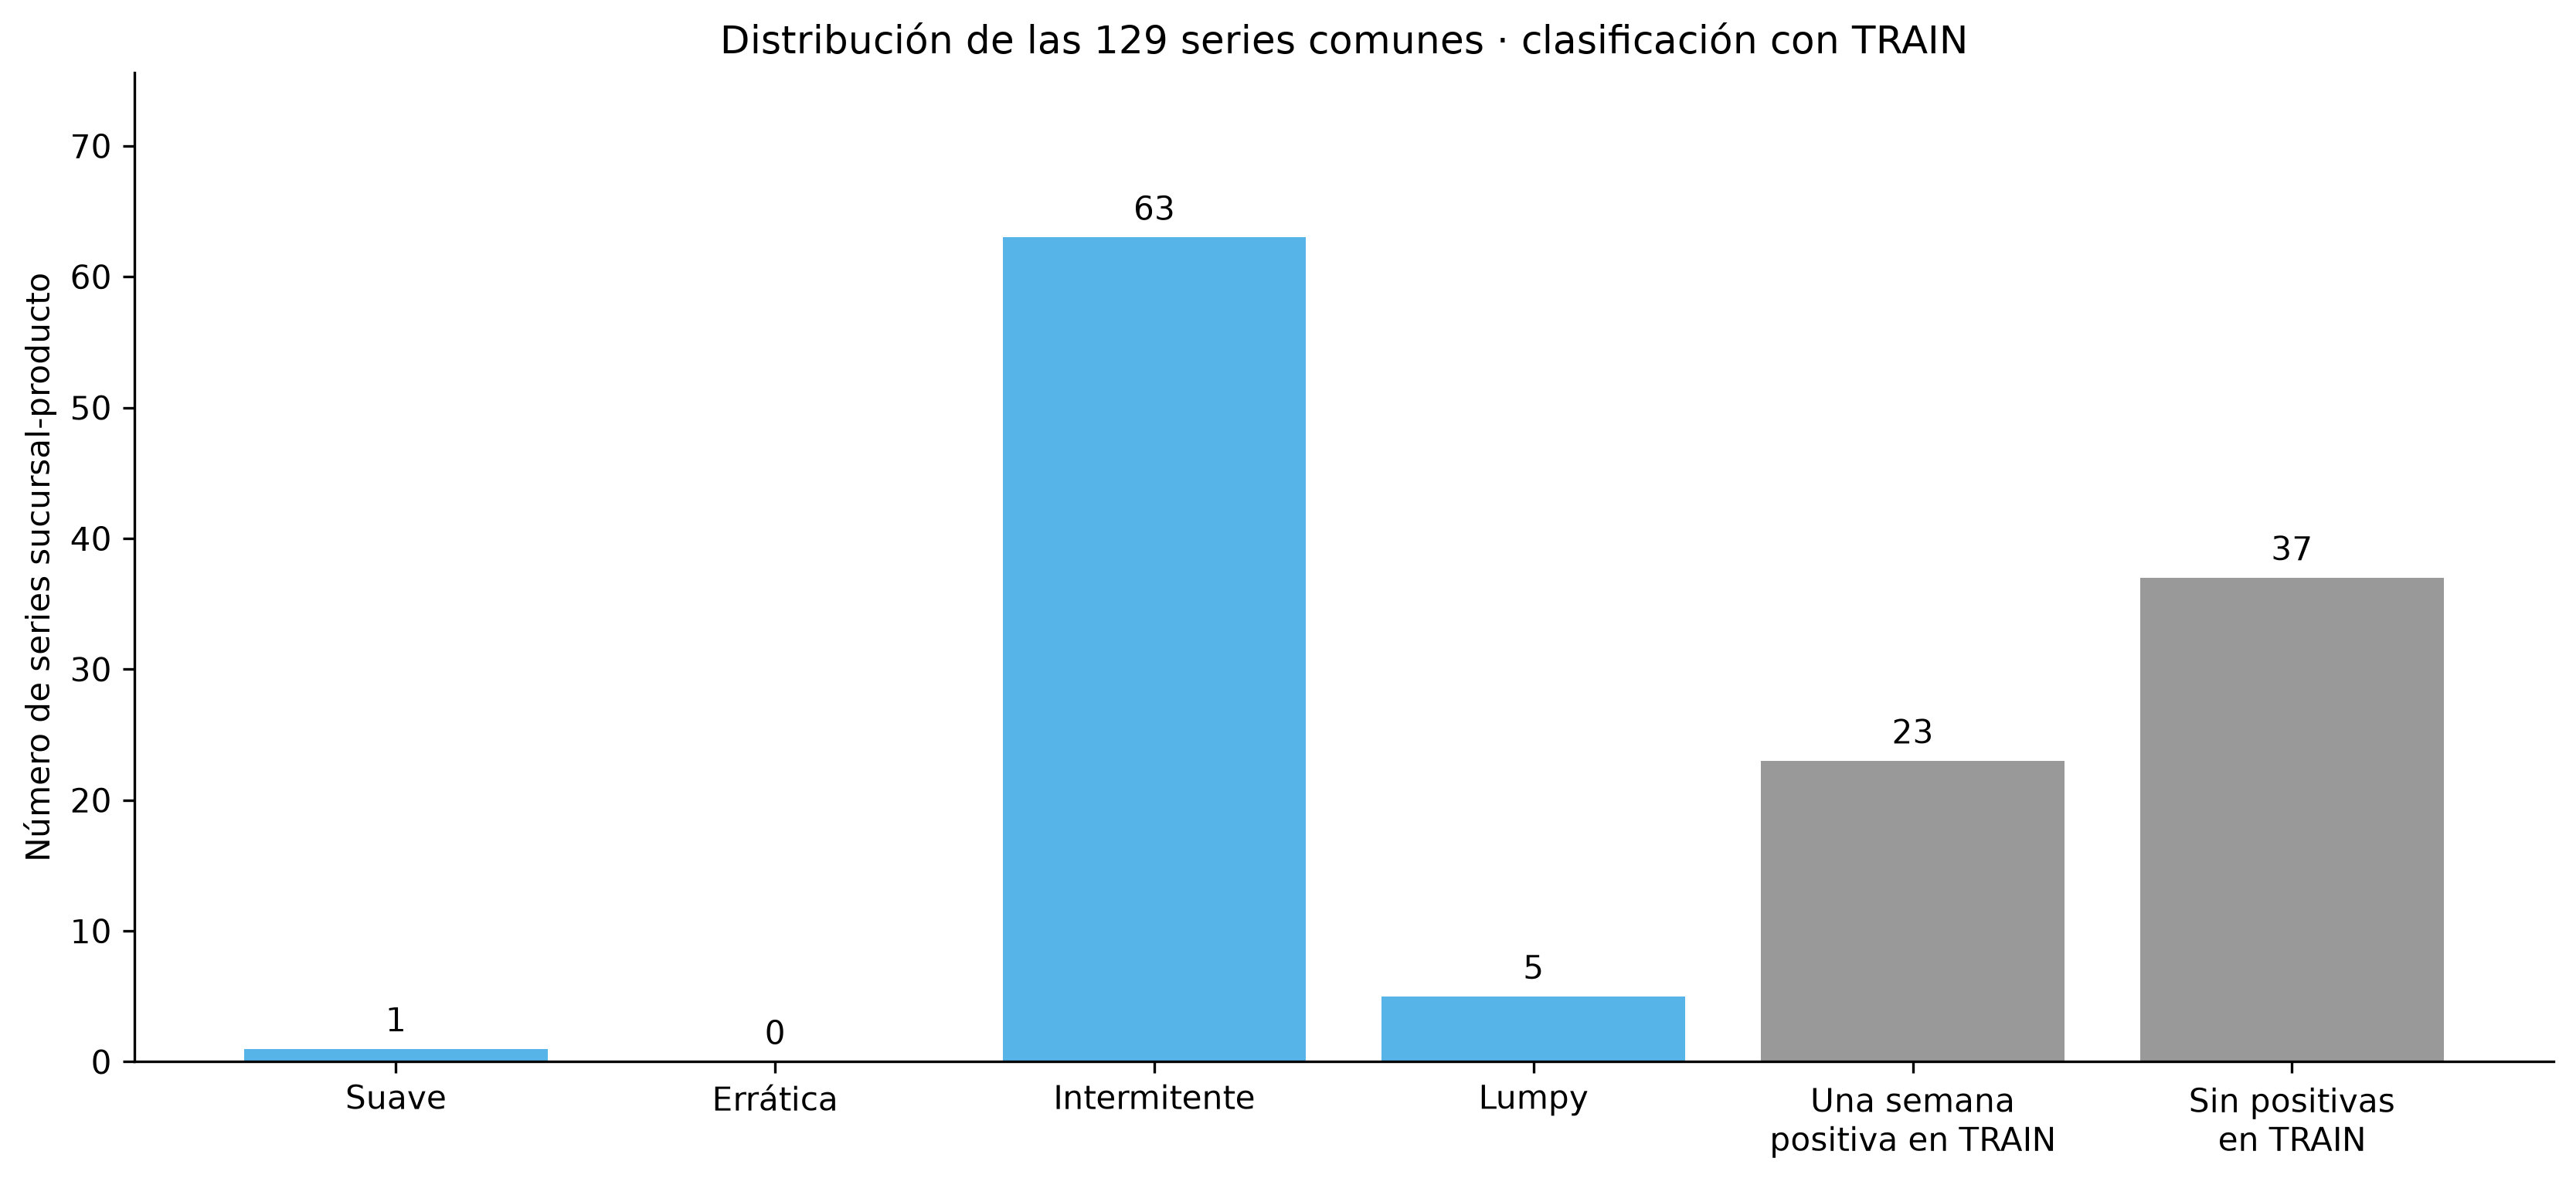

In [2]:
for figura in sorted((ROOT / 'resultados/semanal/figuras_intermitencia').glob('*.png')):
    display(Image(filename=str(figura), width=1000))
